In [260]:
import torch
torch.__version__

'2.9.1+cpu'

In [261]:
import matplotlib.pyplot as plt

In [262]:
from sklearn.datasets import make_circles

x, y = make_circles(n_samples=1000, noise=0.03)
x[:5], y[:10]

(array([[ 0.41478631,  0.90279125],
        [-0.27752288, -0.98067447],
        [-0.15102889, -0.9953172 ],
        [-0.03094944, -0.96452294],
        [-0.98344163, -0.18097922]]),
 array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1]))

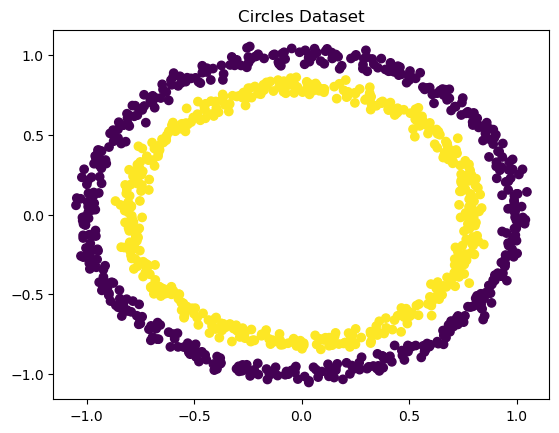

In [263]:
plt.scatter(x[:,0],x[:,1], c=y)
plt.title("Circles Dataset")
plt.show()

In [264]:
X = torch.from_numpy(x).type(torch.float)
Y = torch.from_numpy(y).type(torch.float)

In [265]:
X[:5], Y[:5]

(tensor([[ 0.4148,  0.9028],
         [-0.2775, -0.9807],
         [-0.1510, -0.9953],
         [-0.0309, -0.9645],
         [-0.9834, -0.1810]]),
 tensor([0., 0., 0., 0., 0.]))

In [266]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2)

In [267]:
len(x_train), len(x_test)

(800, 200)

In [268]:
x_train.dtype

torch.float32

In [269]:
x_train.shape, x_train.size()

(torch.Size([800, 2]), torch.Size([800, 2]))

In [270]:
from torch import nn

In [271]:
class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=2, out_features=10)
        self.linear_2 = nn.Linear(in_features=10, out_features=10)
        self.linear_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.linear(x)
        x = self.relu(x)
        x = self.linear_2(x)
        x = self.relu(x)
        x = self.linear_3(x)
        return x
        

In [272]:
model = BinaryClassifier()
model

BinaryClassifier(
  (linear): Linear(in_features=2, out_features=10, bias=True)
  (linear_2): Linear(in_features=10, out_features=10, bias=True)
  (linear_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [273]:
model.state_dict()

OrderedDict([('linear.weight',
              tensor([[ 0.3633,  0.5902],
                      [-0.0768, -0.0540],
                      [ 0.5863,  0.3440],
                      [-0.0633, -0.5458],
                      [ 0.5060, -0.3953],
                      [ 0.0826, -0.4770],
                      [ 0.4113, -0.5304],
                      [ 0.4314,  0.6826],
                      [ 0.1226, -0.6623],
                      [ 0.2905,  0.1331]])),
             ('linear.bias',
              tensor([-0.3867, -0.6237, -0.4639, -0.6995,  0.2862, -0.6934,  0.5087,  0.4221,
                      -0.5503, -0.0930])),
             ('linear_2.weight',
              tensor([[ 0.1064, -0.2083,  0.1868,  0.1802, -0.0894,  0.0451, -0.0878, -0.2518,
                        0.2385, -0.0660],
                      [-0.0678,  0.2298, -0.0864, -0.1209,  0.2007, -0.0489, -0.0394, -0.0350,
                       -0.1788,  0.2318],
                      [ 0.1939, -0.2800, -0.2063,  0.0409, -0.0225,  0.17

In [274]:
from torch.nn import BCEWithLogitsLoss
from torch.optim import SGD

criterion = BCEWithLogitsLoss()
optimizer = SGD(params=model.parameters(), lr=0.01)

In [275]:
from tqdm import tqdm

In [276]:
Epochs = 1000
Training_Loss = []
Testing_loss = []
No_Epoch = []

for epoch in tqdm(range(Epochs)):
    model.train()
    y_logits = model(x_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = criterion(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.inference_mode():
        model.eval()
        y_test_logits = model(x_test).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))
        test_loss = criterion(y_test_logits, y_test)

    if epoch % 100 == 0:
        print(f"___Epoch___{epoch}\n")
        print(f"Loss: {loss:.5f} ||| Test Logits: {test_loss:.5f}")
        No_Epoch.append(epoch)
        Training_Loss.append(loss.item())
        Testing_loss.append(test_loss.item())

  5%|▍         | 47/1000 [00:00<00:02, 460.20it/s]

___Epoch___0

Loss: 0.69402 ||| Test Logits: 0.69268


 19%|█▉        | 189/1000 [00:00<00:01, 416.16it/s]

___Epoch___100

Loss: 0.69310 ||| Test Logits: 0.69244


 28%|██▊       | 278/1000 [00:00<00:01, 425.98it/s]

...

 88%|████████▊ | 876/1000 [00:02<00:00, 424.78it/s]

___Epoch___800

Loss: 0.69143 ||| Test Logits: 0.69244


 96%|█████████▌| 961/1000 [00:02<00:00, 403.08it/s]

___Epoch___900

Loss: 0.69130 ||| Test Logits: 0.69238


100%|██████████| 1000/1000 [00:02<00:00, 412.70it/s]


In [277]:
No_Epoch, Training_Loss, Testing_loss

([0, 100, 200, 300, 400, 500, 600, 700, 800, 900],
 [0.6940249800682068,
  0.6930981278419495,
  0.6926097273826599,
  0.6922897100448608,
  0.692055344581604,
  0.6918637156486511,
  0.691699206829071,
  0.6915561556816101,
  0.6914271712303162,
  0.6912991404533386],
 [0.6926793456077576,
  0.6924359202384949,
  0.6924626231193542,
  0.6925103068351746,
  0.6925367712974548,
  0.6925417184829712,
  0.6925294399261475,
  0.6924967169761658,
  0.6924429535865784,
  0.6923812031745911])

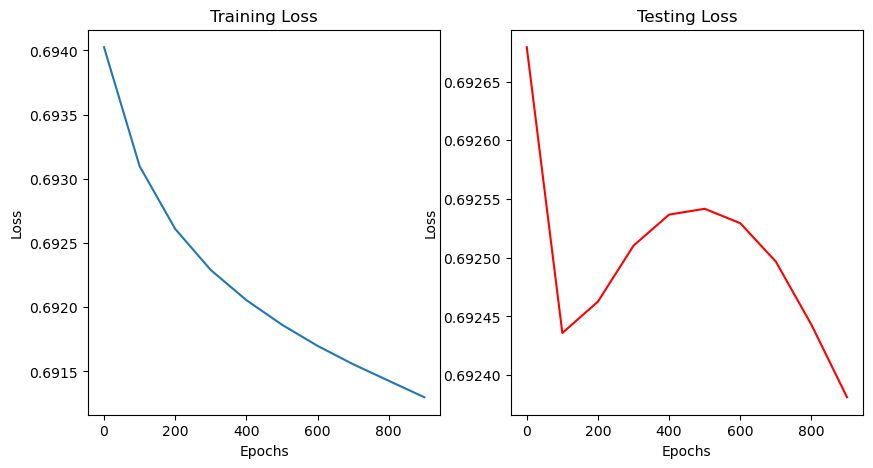

In [278]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].plot(No_Epoch, Training_Loss)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[1].plot(No_Epoch, Testing_loss, c="red")
ax[1].set_title("Testing Loss")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()